In [19]:
import pandas as pd
import numpy as np
import math

import statsmodels.api as sm

df = pd.read_csv("./main_exp.csv") #.rename(columns={"value", "nmi"})

df["solver"] = df["solver"]
df["solver_i"] = df["solver"].map({"sink_one": 1, "sink_many": -1})


DV_pre = ["test_accuracy", "test_region_nmi", "test_power_entropy", "test_speaker_entropy"]
IV = ["load_lambda", "solver_i"]

DV = []
for dv in DV_pre:
    DV.append(f"logit_{dv}")
    df[f"logit_{dv}"] = np.log(df[dv] / (1 - df[dv]))


# df['logit_nmi'] = np.log(df['nmi'] / (1 - df['nmi']))


In [33]:
means = df.groupby(["load_lambda", "solver"])[DV_pre].mean()

i_ba = means["test_accuracy"].argmax()
i_bn = means["test_region_nmi"].argmax()
i_bp = means["test_power_entropy"].argmin()
i_bs = means["test_speaker_entropy"].argmax()


print("test_accuracy")
print(means.index[i_ba], means.loc[means.index[i_ba], "test_accuracy"])
print("test_region_nmi")
print(means.index[i_bn], means.loc[means.index[i_bn], "test_region_nmi"])
print("test_power_entropy")
print(means.index[i_bp], means.loc[means.index[i_bp], "test_power_entropy"])
print("test_speaker_entropy")
print(means.index[i_bs], means.loc[means.index[i_bs], "test_speaker_entropy"])


test_accuracy
(np.float64(0.2154434690031883), 'sink_one') 0.909275
test_region_nmi
(np.float64(0.2154434690031883), 'sink_many') 0.2456891084431828
test_power_entropy
(np.float64(1.0), 'sink_many') 0.14547006785869596
test_speaker_entropy
(np.float64(0.4641588833612778), 'sink_many') 0.9685048684477806


In [13]:
import statsmodels.formula.api as smf


def summary(dv: str):

    print(f"\n\n ---------------{dv}--------------\n")
    formula = f"{dv} ~ {IV[0]} * {IV[1]}"
    model = smf.ols(formula=formula, data=df).fit()

    print(model.summary())

for dv in DV:
    summary(dv)



 ---------------logit_test_accuracy--------------

                             OLS Regression Results                            
Dep. Variable:     logit_test_accuracy   R-squared:                       0.016
Model:                             OLS   Adj. R-squared:                  0.016
Method:                  Least Squares   F-statistic:                     183.7
Date:                 Fri, 11 Apr 2025   Prob (F-statistic):          3.79e-118
Time:                         11:24:08   Log-Likelihood:                 312.96
No. Observations:                33600   AIC:                            -617.9
Df Residuals:                    33596   BIC:                            -584.2
Df Model:                            3                                         
Covariance Type:             nonrobust                                         
                           coef    std err          t      P>|t|      [0.025      0.975]
----------------------------------------------------------

In [64]:
df.iloc[df["nmi"].argmax()]

trial               69.000000
nmi                  0.820183
b                    1.000000
c                    3.000000
d                    2.000000
load_lambda          0.746461
layer_times_step     1.000000
network_width       80.000000
logit_nmi            1.517585
Name: 69, dtype: float64

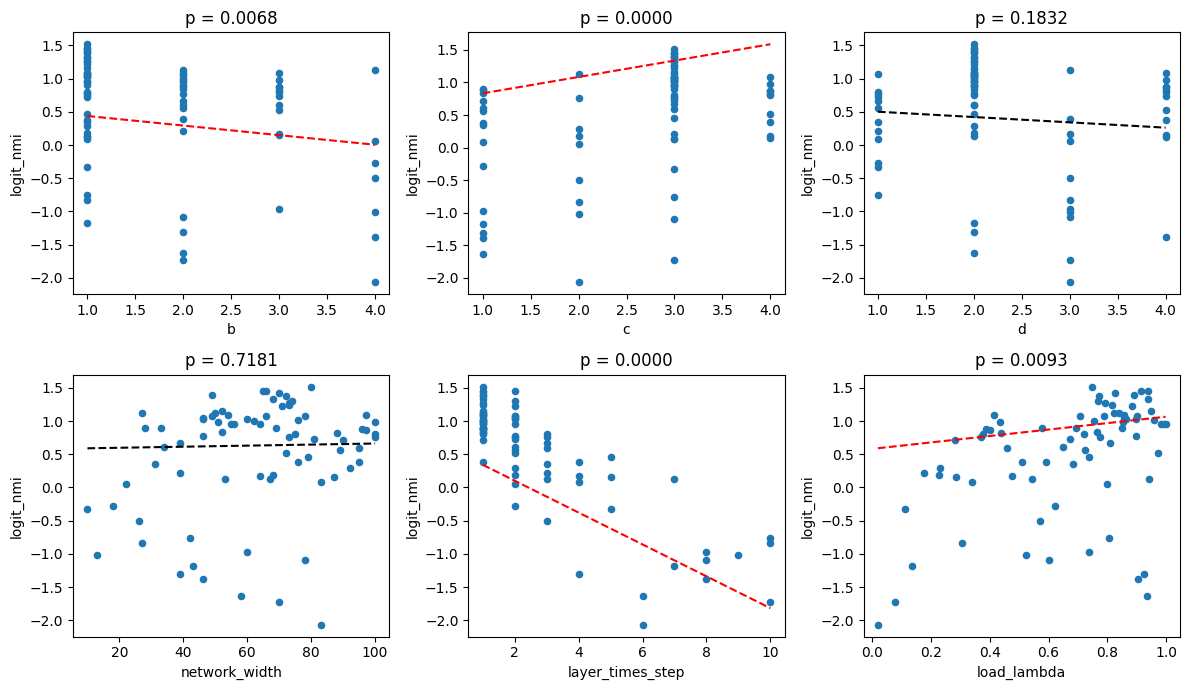

In [67]:
from matplotlib import pyplot as plt

DV = "logit_nmi"
IV = ['b', 'c', 'd', 'network_width', 'layer_times_step', 'load_lambda']

fig, axs = plt.subplots(2, 3, figsize=(12, 7))

for ax, iv in zip(axs.ravel(), IV):
    df.plot.scatter(iv, DV, ax=ax)

    # p-value
    p_val = model.pvalues[iv]

    # Regression line
    x_vals = df[iv]
    x_fit = np.linspace(x_vals.min(), x_vals.max(), 100)
    y_fit = model.params['const'] + model.params[iv] * x_fit
    color = "black" if p_val > 0.05 else "red"
    ax.plot(x_fit, y_fit, '--', color=color)  # dashed line

    ax.set_title(f"p = {p_val:.4f}")

fig.tight_layout()
fig.savefig("./figures/exp_nmi_statistical.pdf")

In [ ]:
fig.